In [1]:
import os 
os.environ["OMP_NUM_THREADS"] = "3"

In [2]:
# Level 1 Task 1- Data Cleaning and PreProcessing 

In [3]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('churn-bigml-20.csv')

In [4]:
# Initial inspection
print("BEFORE CLEANING")
print(f"Shape: {df.shape}")
print(f"\nColumn dtypes:\n{df.dtypes}")
print(f"\nMissing values per column:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nSample of categorical columns:")
print(df[['State', 'International plan', 'Voice mail plan', 'Churn']].head())

BEFORE CLEANING
Shape: (667, 20)

Column dtypes:
State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object

Missing values per column:
State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total

In [5]:
# Handle missing values
# No missing values were found, but this is how we'd handle them if present
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

In [6]:
# Categorical columns -> fill with mode (most frequent value)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

In [7]:
# Remove duplicate rows
before_rows = df.shape[0]
df = df.drop_duplicates()
after_rows = df.shape[0]
print(f"\nRemoved {before_rows - after_rows} duplicate rows")


Removed 0 duplicate rows


In [8]:
# --- Standardize inconsistent formats ---
# Strip whitespace and fix casing on text columns
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

# Standardize Yes/No columns into clean binary flags (0/1) for easier analysis
df['International plan'] = df['International plan'].map({'Yes': 1, 'No': 0})
df['Voice mail plan'] = df['Voice mail plan'].map({'Yes': 1, 'No': 0})

# Ensure Churn is a proper boolean/int (True/False -> 1/0)
df['Churn'] = df['Churn'].astype(bool).astype(int)

# Clean up column names: lowercase, underscores instead of spaces
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [9]:
# --- AFTER: Confirm the cleaning worked ---
print("\n=== AFTER CLEANING ===")
print(f"Shape: {df.shape}")
print(f"\nMissing values per column:\n{df.isnull().sum().sum()} total")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"\nUpdated dtypes:\n{df.dtypes}")
print(f"\nSample of cleaned data:")
print(df[['state', 'international_plan', 'voice_mail_plan', 'churn']].head())


=== AFTER CLEANING ===
Shape: (667, 20)

Missing values per column:
0 total
Duplicate rows: 0

Updated dtypes:
state                      object
account_length              int64
area_code                   int64
international_plan          int64
voice_mail_plan             int64
number_vmail_messages       int64
total_day_minutes         float64
total_day_calls             int64
total_day_charge          float64
total_eve_minutes         float64
total_eve_calls             int64
total_eve_charge          float64
total_night_minutes       float64
total_night_calls           int64
total_night_charge        float64
total_intl_minutes        float64
total_intl_calls            int64
total_intl_charge         float64
customer_service_calls      int64
churn                       int64
dtype: object

Sample of cleaned data:
  state  international_plan  voice_mail_plan  churn
0    LA                   0                0      0
1    IN                   0                0      1
2    NY      

In [10]:
# Save the cleaned dataset for use in later tasks
df.to_csv('churn_cleaned.csv', index=False)
print("\nCleaned dataset saved as 'churn_cleaned.csv'")


Cleaned dataset saved as 'churn_cleaned.csv'


In [11]:
# Level 1 Task 3- Basic Data Visualization

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent style for all plots
sns.set_style('whitegrid')

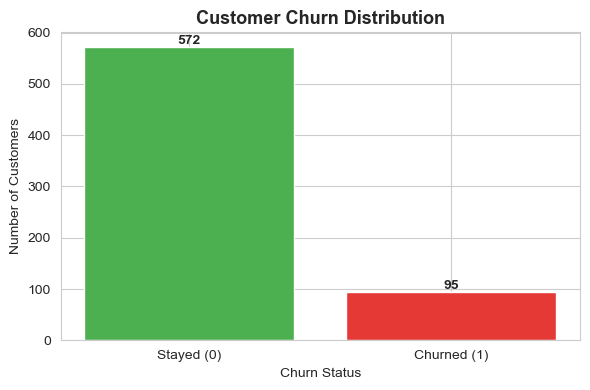

In [13]:
# Bar plot
plt.figure(figsize=(6, 4))
churn_counts = df['churn'].value_counts()
plt.bar(['Stayed (0)', 'Churned (1)'], churn_counts.values, color=['#4CAF50', '#E53935'])
plt.title('Customer Churn Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

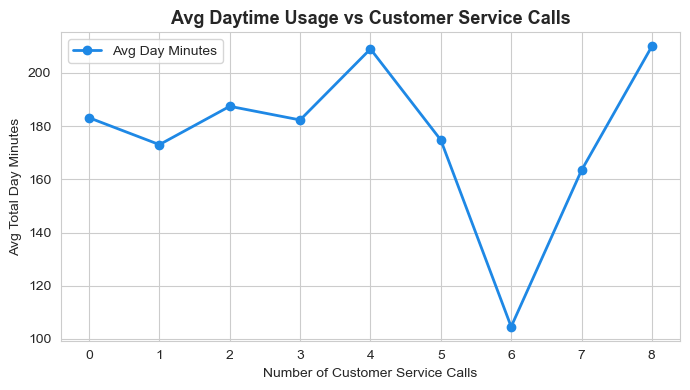

In [14]:
# Line chart
plt.figure(figsize=(7, 4))
avg_minutes = df.groupby('customer_service_calls')['total_day_minutes'].mean()
plt.plot(avg_minutes.index, avg_minutes.values, marker='o', color='#1E88E5', linewidth=2)
plt.title('Avg Daytime Usage vs Customer Service Calls', fontsize=13, fontweight='bold')
plt.xlabel('Number of Customer Service Calls')
plt.ylabel('Avg Total Day Minutes')
plt.legend(['Avg Day Minutes'])
plt.tight_layout()
plt.show()

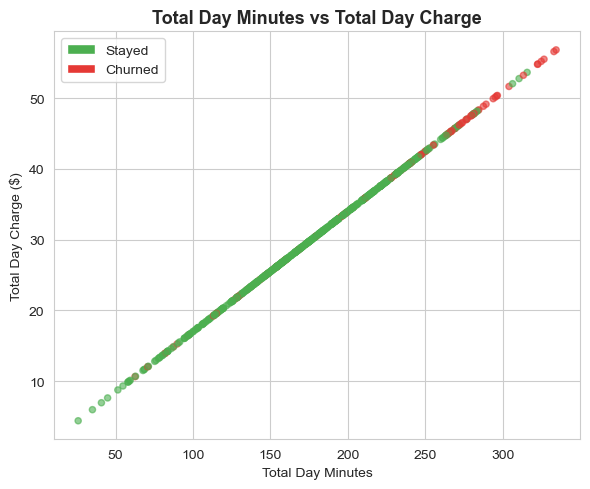

In [15]:
# Scatter plot
plt.figure(figsize=(6, 5))
colors = df['churn'].map({0: '#4CAF50', 1: '#E53935'})
plt.scatter(df['total_day_minutes'], df['total_day_charge'], c=colors, alpha=0.6, s=20)
plt.title('Total Day Minutes vs Total Day Charge', fontsize=13, fontweight='bold')
plt.xlabel('Total Day Minutes')
plt.ylabel('Total Day Charge ($)')
# Manual legend since we used a color map
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4CAF50', label='Stayed'),
                   Patch(facecolor='#E53935', label='Churned')]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

In [16]:
# Level 2 Task 1- Regression Analysis

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [18]:
# Define predictor (X) and target (y)
X = df[['total_day_minutes']]  
y = df['total_day_charge']      

print("DATA OVERVIEW")
print(f"Predictor (total_day_minutes) range: {X['total_day_minutes'].min()} - {X['total_day_minutes'].max()}")
print(f"Target (total_day_charge) range: {y.min()} - {y.max()}")

DATA OVERVIEW
Predictor (total_day_minutes) range: 25.9 - 334.3
Target (total_day_charge) range: 4.4 - 56.83


In [19]:
# Split into training and testing sets 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTraining set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")


Training set size: 533 rows
Testing set size: 134 rows


In [20]:
# Fit a linear regression model 
model = LinearRegression()
model.fit(X_train, y_train)

# Interpret the coefficients 
print("\nMODEL COEFFICIENTS")
print(f"Intercept: {model.intercept_:.4f}")
print(f"Coefficient (slope) for total_day_minutes: {model.coef_[0]:.4f}")
print(f"\nInterpretation: for every 1 extra minute of daytime usage, "
      f"total day charge increases by ~${model.coef_[0]:.4f}")


MODEL COEFFICIENTS
Intercept: 0.0003
Coefficient (slope) for total_day_minutes: 0.1700

Interpretation: for every 1 extra minute of daytime usage, total day charge increases by ~$0.1700


In [21]:
# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\nMODEL EVALUATION")
print(f"R-squared: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")


MODEL EVALUATION
R-squared: 1.0000
Mean Squared Error: 0.0000
Root Mean Squared Error: 0.0028


In [22]:
# Before/after comparison: actual vs predicted sample
comparison = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': y_pred[:10].round(2)})
print("\nSAMPLE PREDICTIONS (first 10 test rows)")
print(comparison)


SAMPLE PREDICTIONS (first 10 test rows)
   Actual  Predicted
0   34.65      34.65
1   33.41      33.41
2   39.22      39.22
3   26.50      26.50
4   39.54      39.54
5   24.09      24.09
6   26.01      26.01
7   24.57      24.57
8   38.40      38.40
9   18.09      18.09


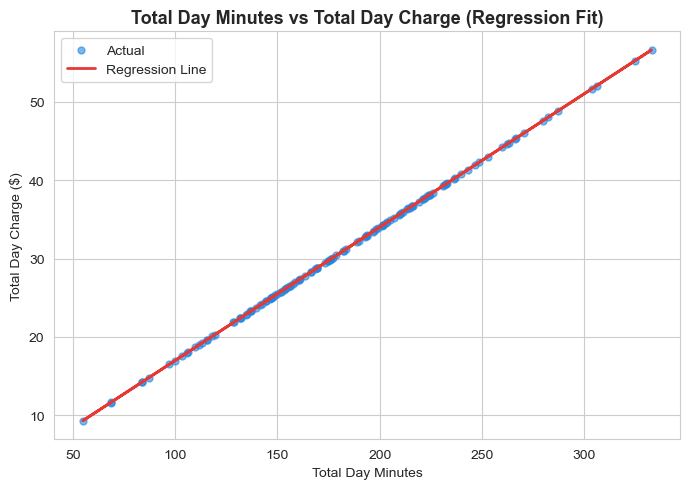

In [23]:
# Visualize the regression fit
plt.figure(figsize=(7, 5))
plt.scatter(X_test, y_test, color='#1E88E5', alpha=0.6, label='Actual', s=25)
plt.plot(X_test, y_pred, color='#E53935', linewidth=2, label='Regression Line')
plt.title('Total Day Minutes vs Total Day Charge (Regression Fit)', fontsize=13, fontweight='bold')
plt.xlabel('Total Day Minutes')
plt.ylabel('Total Day Charge ($)')
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
# Level 2 Task 3- Clustering Analysis (K-Means)

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [26]:
# Select numeric features for clustering (drop categorical/target columns)
cluster_features = [
    'account_length', 'number_vmail_messages', 'total_day_minutes',
    'total_day_calls', 'total_eve_minutes', 'total_eve_calls',
    'total_night_minutes', 'total_night_calls', 'total_intl_minutes',
    'total_intl_calls', 'customer_service_calls'
]
X = df[cluster_features]

print("BEFORE SCALING")
print(X.describe().loc[['mean', 'std']])

# Standardize the dataset 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nAFTER SCALING")
print(f"Mean (should be ~0): {X_scaled.mean(axis=0).round(2)}")
print(f"Std (should be ~1): {X_scaled.std(axis=0).round(2)}")

BEFORE SCALING
      account_length  number_vmail_messages  total_day_minutes  \
mean      102.841079               8.407796         180.948126   
std        40.819480              13.994480          55.508628   

      total_day_calls  total_eve_minutes  total_eve_calls  \
mean       100.937031         203.355322       100.476762   
std         20.396790          49.719268        18.948262   

      total_night_minutes  total_night_calls  total_intl_minutes  \
mean           199.685307         100.113943           10.238381   
std             49.759931          20.172505            2.807850   

      total_intl_calls  customer_service_calls  
mean          4.527736                1.563718  
std           2.482442                1.333357  

AFTER SCALING
Mean (should be ~0): [-0.  0.  0. -0.  0.  0. -0. -0. -0.  0. -0.]
Std (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


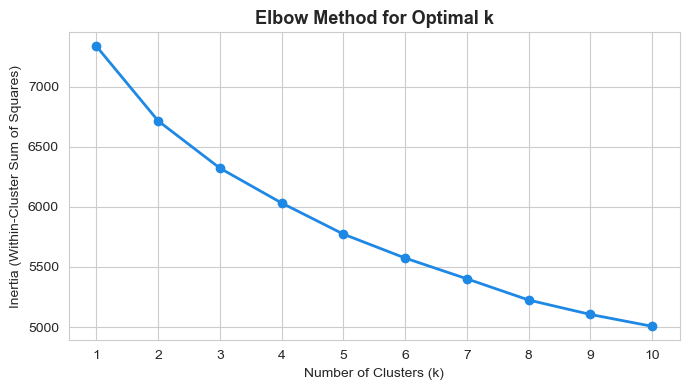

In [27]:
# Elbow method to find optimal number of clusters
inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertias, marker='o', color='#1E88E5', linewidth=2)
plt.title('Elbow Method for Optimal k', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

In [28]:
# Apply K-Means with chosen k
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"\nCLUSTERING RESULTS (k={optimal_k})")
print(df['cluster'].value_counts().sort_index())
print("\nCluster centers (mean values per feature, original scale):")
print(df.groupby('cluster')[cluster_features].mean().round(1))


CLUSTERING RESULTS (k=3)
cluster
0    248
1    249
2    170
Name: count, dtype: int64

Cluster centers (mean values per feature, original scale):
         account_length  number_vmail_messages  total_day_minutes  \
cluster                                                             
0                  90.2                    0.6              167.5   
1                 115.8                    0.9              200.7   
2                 102.3                   30.9              171.7   

         total_day_calls  total_eve_minutes  total_eve_calls  \
cluster                                                        
0                  101.9              200.3             93.6   
1                  100.6              203.2            108.6   
2                  100.0              208.1             98.7   

         total_night_minutes  total_night_calls  total_intl_minutes  \
cluster                                                               
0                      225.0              10

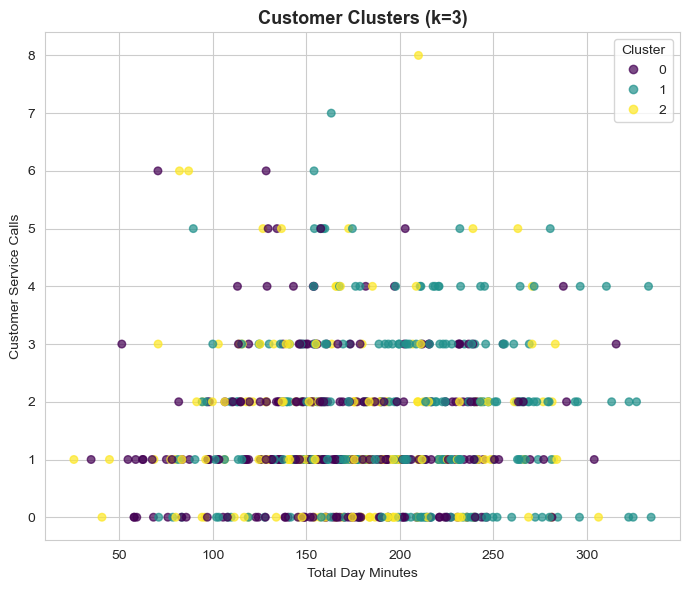

In [29]:
# Visualize clusters using 2D scatter plot
plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    df['total_day_minutes'], df['customer_service_calls'],
    c=df['cluster'], cmap='viridis', alpha=0.7, s=30
)
plt.title(f'Customer Clusters (k={optimal_k})', fontsize=13, fontweight='bold')
plt.xlabel('Total Day Minutes')
plt.ylabel('Customer Service Calls')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.tight_layout()
plt.show()

In [ ]:
# Level 3 Task 1- Predictive Modeling (Classification)

In [30]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [31]:
# Preprocess: encode remaining categorical variable ('state')
print("BEFORE PREPROCESSING")
print(df.dtypes)

le = LabelEncoder()
df['state_encoded'] = le.fit_transform(df['state'])

# Drop original text column and area_code (not predictive, just a phone prefix)
feature_cols = [c for c in df.columns if c not in ['state', 'churn', 'cluster', 'area_code']]
X = df[feature_cols]
y = df['churn']

print("\nAFTER PREPROCESSING ")
print(f"Feature columns used: {feature_cols}")
print(f"Target distribution:\n{y.value_counts()}")

BEFORE PREPROCESSING
state                      object
account_length              int64
area_code                   int64
international_plan          int64
voice_mail_plan             int64
number_vmail_messages       int64
total_day_minutes         float64
total_day_calls             int64
total_day_charge          float64
total_eve_minutes         float64
total_eve_calls             int64
total_eve_charge          float64
total_night_minutes       float64
total_night_calls           int64
total_night_charge        float64
total_intl_minutes        float64
total_intl_calls            int64
total_intl_charge         float64
customer_service_calls      int64
churn                       int64
cluster                     int32
dtype: object

AFTER PREPROCESSING 
Feature columns used: ['account_length', 'international_plan', 'voice_mail_plan', 'number_vmail_messages', 'total_day_minutes', 'total_day_calls', 'total_day_charge', 'total_eve_minutes', 'total_eve_calls', 'total_eve_charge', 't

In [32]:
# Split into training and testing sets 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set: {X_train.shape[0]} rows, Testing set: {X_test.shape[0]} rows")


Training set: 533 rows, Testing set: 134 rows


In [33]:
# Train and evaluate multiple models 
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-score': f1})

results_df = pd.DataFrame(results)
print("\n=== MODEL COMPARISON (before tuning) ===")
print(results_df.round(4))


=== MODEL COMPARISON (before tuning) ===
                 Model  Accuracy  Precision  Recall  F1-score
0  Logistic Regression    0.8582     0.5000  0.1579    0.2400
1        Decision Tree    0.9328     0.8125  0.6842    0.7429
2        Random Forest    0.9328     1.0000  0.5263    0.6897


In [37]:
# Hyperparameter tuning with GridSearchCV on the best-performing model type: Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print("\nGRID SEARCH RESULTS")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validated F1-score: {grid_search.best_score_:.4f}")


=== GRID SEARCH RESULTS ===
Best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 300}
Best cross-validated F1-score: 0.5965


In [35]:
# Evaluate the tuned model on the test set 
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test_scaled)

print("\n=== TUNED RANDOM FOREST — TEST SET PERFORMANCE ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_tuned):.4f}")
print(f"\nFull classification report:\n{classification_report(y_test, y_pred_tuned)}")


=== TUNED RANDOM FOREST — TEST SET PERFORMANCE ===
Accuracy:  0.9254
Precision: 0.9091
Recall:    0.5263
F1-score:  0.6667

Full classification report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       115
           1       0.91      0.53      0.67        19

    accuracy                           0.93       134
   macro avg       0.92      0.76      0.81       134
weighted avg       0.92      0.93      0.92       134




=== TOP 5 MOST IMPORTANT FEATURES ===
total_day_charge          0.150528
total_day_minutes         0.136793
customer_service_calls    0.117267
total_eve_minutes         0.088247
total_eve_charge          0.079318
dtype: float64


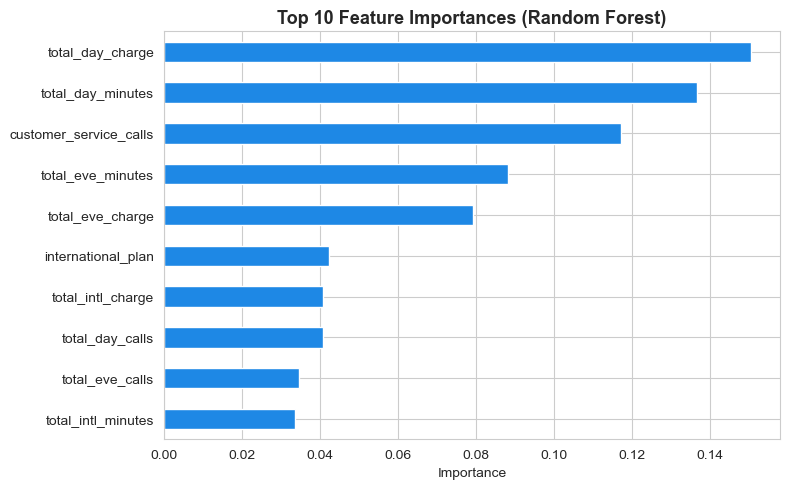

In [36]:
# Feature importance from tuned Random Forest
importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\n=== TOP 5 MOST IMPORTANT FEATURES ===")
print(importances.head(5))

plt.figure(figsize=(8, 5))
importances.head(10).plot(kind='barh', color='#1E88E5')
plt.title('Top 10 Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()